<a href="https://colab.research.google.com/github/Bhavyaa16/Celebel-excelence-internship-assignments/blob/main/week4_BhavyaChauthramani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import pandas as pd

print("Tensorflow version : " , tf.__version__)

Tensorflow version :  2.20.0


LOADING AND NORMALISING THE CIFAR10 DATASET



In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3825s 22us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


ANN MODEL WITH INCREASED LAYERS

In [3]:
ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING ANN USING 10 EPOCHS

In [4]:
history_ann = ann_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.2316 - loss: 2.0778 - val_accuracy: 0.3161 - val_loss: 1.8799
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2900 - loss: 1.9258 - val_accuracy: 0.3381 - val_loss: 1.8437
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3087 - loss: 1.8844 - val_accuracy: 0.3652 - val_loss: 1.8400
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3202 - loss: 1.8520 - val_accuracy: 0.3349 - val_loss: 1.8645
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3210 - loss: 1.8431 - val_accuracy: 0.3476 - val_loss: 1.8240
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3324 - loss: 1.8231 - val_accuracy: 0.3746 - val_loss: 1.7944
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3413 - loss: 1.8059 - val_accuracy: 0.3790 - val_loss: 1.7979
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3430 - loss: 1.8014 - val_accuracy: 

CNN MODEL(32 -> 64 -> 128)

In [ ]:
cnn_model = models.Sequential([

    layers.Conv2D(32,(3,3),padding='same',
                  activation='relu',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same',
                  activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

TRAINING CNN(10 EPOCHS)

In [ ]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    verbose=1
)

ACCURACY CURVES(ANN vs CNN)

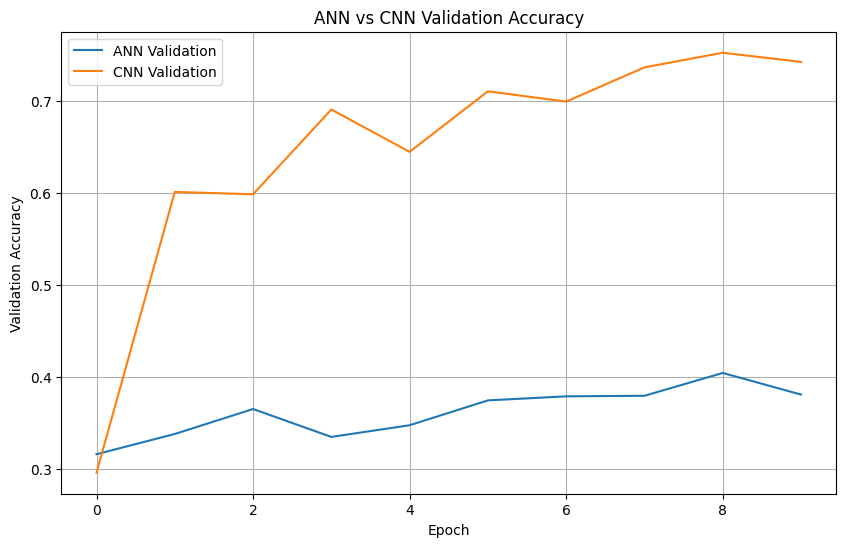

In [7]:
plt.figure(figsize=(10,6))

plt.plot(history_ann.history['val_accuracy'],
         label='ANN Validation')

plt.plot(history_cnn.history['val_accuracy'],
         label='CNN Validation')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
ann_loss, ann_acc = ann_model.evaluate(x_test,y_test)

cnn_loss, cnn_acc = cnn_model.evaluate(x_test,y_test)

DATA AUGMENTATION

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

ADV CNN AND AUGMENTATION

In [10]:
advanced_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(64,(3,3),
                  activation='relu',
                  padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),

    layers.Conv2D(64,(3,3),
                  activation='relu',
                  padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),
                  activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.Conv2D(128,(3,3),
                  activation='relu',
                  padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256,(3,3),
                  activation='relu',
                  padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10,activation='softmax')
])

In [11]:
advanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EARLY STOPPING

In [12]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

TRAINING ADVANCE MODEL (20 EPOCHS)

In [13]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
history_advanced = advanced_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.3294 - loss: 1.8938 - val_accuracy: 0.1722 - val_loss: 2.9345
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.4493 - loss: 1.5184 - val_accuracy: 0.4661 - val_loss: 1.4993
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.5274 - loss: 1.3350 - val_accuracy: 0.5489 - val_loss: 1.2704
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.5816 - loss: 1.1966 - val_accuracy: 0.5999 - val_loss: 1.1467
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6230 - loss: 1.0911 - val_accuracy: 0.5791 - val_loss: 1.2205
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.6507 - loss: 1.0169 - val_accuracy: 0.6801 - val_loss: 0.9697
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.6718 - loss: 0.9563 - val_accuracy: 0.5787 - val_loss: 1.1737
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.6974 - loss: 0.8942 - 

In [ ]:
adv_loss, adv_acc = advanced_model.evaluate(x_test,y_test)

ACCURACY CURVES COMPARSION

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_ann.history['val_accuracy'],
         label='ANN')

plt.plot(history_cnn.history['val_accuracy'],
         label='CNN')

plt.plot(history_advanced.history['val_accuracy'],
         label='Advanced CNN')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()
plt.show()

LOSS CURVES COMPARSION

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_ann.history['val_loss'],
         label='ANN')

plt.plot(history_cnn.history['val_loss'],
         label='CNN')

plt.plot(history_advanced.history['val_loss'],
         label='Advanced CNN')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()
plt.show()

GENERALISED COMPARSION

In [ ]:
generalization_df = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "Advanced CNN"
    ],

    "Train Accuracy (%)":[
        round(history_ann.history['accuracy'][-1]*100,2),
        round(history_cnn.history['accuracy'][-1]*100,2),
        round(history_advanced.history['accuracy'][-1]*100,2)
    ],

    "Validation Accuracy (%)":[
        round(history_ann.history['val_accuracy'][-1]*100,2),
        round(history_cnn.history['val_accuracy'][-1]*100,2),
        round(history_advanced.history['val_accuracy'][-1]*100,2)
    ]
})

generalization_df

TRAINING STRATEGY COMPARSION

In [ ]:
strategy_df = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "Advanced CNN"
    ],

    "Dropout":[
        "Yes",
        "Yes",
        "Yes"
    ],

    "Batch Normalization":[
        "No",
        "Yes",
        "Yes"
    ],

    "Data Augmentation":[
        "No",
        "No",
        "Yes"
    ],

    "Epochs":[
        10,
        10,
        20
    ]
})

strategy_df

PERFORMANCE COMPARSION

In [ ]:
final_df = pd.DataFrame({

    "Model":[
        "ANN",
        "CNN",
        "Advanced CNN + Augmentation"
    ],

    "Test Accuracy (%)":[
        round(ann_acc*100,2),
        round(cnn_acc*100,2),
        round(adv_acc*100,2)
    ],

    "Generalization":[
        "Moderate",
        "Good",
        "Best"
    ],

    "Training Strategy":[
        "Dropout",
        "Dropout + BatchNorm",
        "Dropout + BatchNorm + Augmentation + EarlyStopping"
    ]
})

final_df

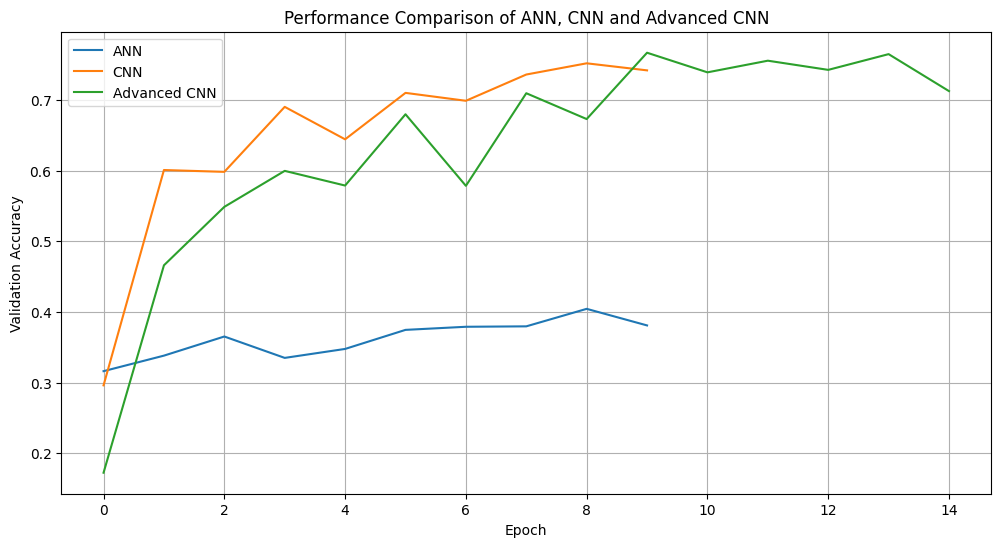

In [21]:
plt.figure(figsize=(12,6))

plt.plot(history_ann.history['val_accuracy'],
         label='ANN')

plt.plot(history_cnn.history['val_accuracy'],
         label='CNN')

plt.plot(history_advanced.history['val_accuracy'],
         label='Advanced CNN')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Performance Comparison of ANN, CNN and Advanced CNN")
plt.legend()
plt.grid()
plt.show()